# Week 10 - Modules Part 2: Introduction to pandas

This week we will be introducing another important module, pandas, which is used to access, analyse and manipulate data. 

We import this package identically to how we imported numpy last week. The name abbreviation most commonly used in data science is pd.

In [1]:
import pandas as pd

## 1.1 Importing data

Once we have imported the package we can use it to load in a file. The most common type of data file format we use are **comma-separated value** (csv) files. To open these we use the pandas method read_csv(), with the necessary argument specifying the filename as a string. This week we are working with some example SCADA data from *Kaggle* available [here](https://www.kaggle.com/code/kerneler/starter-wind-turbine-scada-dataset-eaa6e30d-2), which has been modified for this tutorial. Kaggle is a website which provides lots of useful open-source and practice datasets as well as tutorials. This site hosts a more extensive [tutorial](https://www.kaggle.com/learn/pandas) on how to learn pandas for anyone interested in going more in-depth.

In [2]:
data = pd.read_csv('example_data.csv')

## 1.1 - Viewing the data

With any new imported dataset we want to take a high-level look into the structure, data and information it holds. Firstly, we can use the columns attribute to see column names. This can help us understand what variables we have to work with. Most good-quality datasets will come equipped with named variables, however some data will need investigating to understand what variables we have present.

In [3]:
data.columns

Index(['Date/Time', 'LV ActivePower (kW)', 'Wind Speed (m/s)',
       'Theoretical_Power_Curve (KWh)', 'Wind Direction (°)',
       'Standard Deviation'],
      dtype='object')

Here we have date and time information, active power, wind speed, theoretical power, wind direction and standard deviation. These are all typical summary statistics within SCADA data. In general, these will be mean values over a sample time frame, usually 10-minutes.

We can then use the .head() and .tail() methods to view the top and bottom of the dataframe. By default these take no arguments and display the first and last 5 rows of data respectively. We may optionally specify the number of rows we wish to view. This allows us to see the format of the variables, and get an idea of what the data looks like. This step is important to check the data is in-line with what we'd expect. For example, if wind direction is measured in degrees values should be numerical between 0 and 360.

In [4]:
data.head()

,Date/Time,LV ActivePower (kW),Wind Speed (m/s),Theoretical_Power_Curve (KWh),Wind Direction (°),Standard Deviation
0,01 01 2018 00:00,380.047791,5.311336,416.328908,259.994904,0.257970
1,01 01 2018 00:10,453.769196,5.672167,519.917511,268.641113,0.290311
2,01 01 2018 00:20,306.376587,5.216037,390.900016,272.564789,0.430421
3,01 01 2018 00:30,419.645905,5.659674,516.127569,271.258087,1.428785
4,01 01 2018 00:40,380.650696,5.577941,491.702972,265.674286,NaN


In [5]:
data.tail(10)

,Date/Time,LV ActivePower (kW),Wind Speed (m/s),Theoretical_Power_Curve (KWh),Wind Direction (°),Standard Deviation
50520,31 12 2018 22:20,2771.110107,10.154550,2884.512812,82.335197,0.525878
50521,31 12 2018 22:30,3333.819092,12.067660,3532.081496,81.985901,0.651726
50522,31 12 2018 22:40,3455.282959,12.195660,3549.150371,82.210617,0.036548
50523,31 12 2018 22:50,3429.021973,12.492510,3578.567804,82.111870,0.721691
50524,31 12 2018 23:00,3514.269043,12.559170,3583.288363,80.495262,1.097407
50525,31 12 2018 23:10,2963.980957,11.404030,3397.190793,80.502724,0.807799
50526,31 12 2018 23:20,1684.353027,7.332648,1173.055771,84.062599,0.488488
50527,31 12 2018 23:30,2201.106934,8.435358,1788.284755,84.742500,0.494200
50528,31 12 2018 23:40,2515.694092,9.421366,2418.382503,84.297913,1.061639
50529,31 12 2018 23:50,2820.466064,9.979332,2779.184096,82.274620,0.524768


Looking at the tail allows us to see the row number of the final entry which shows us how long the dataset is. We can also access this using the in-built Python len() method.

In [6]:
len(data)

50530

## 1.3 - Editing the data
We want to make the data as usable as possible. The first thing we may notice is that the column titles are long and a little tricky to work with. We may rename these using the rename() method. This is done by specifying columns by a dictionary mapping old names to new names. 

In pandas we may access columns as attributes provided they comply with attribute naming rules i.e.:
- No spaces
- Only using letters, numbers and underscores
- Starting with a letter or an underscore

Another important thing to note is that the rename function returns a new dataframe, rather than editing in place. This means we need to assign it to the original name to redefine the dataframe. With pandas this is an important distinction that must be checked with different pandas methods. Some will instead return nothing, editing in place. For these methods using the below syntax would overwrite the dataframe as null.

In [7]:
rename_dict = {'Date/Time':'DateTime', 'LV ActivePower (kW)': 'ActivePower', 'Wind Speed (m/s)':'Spd', 
                     'Theoretical_Power_Curve (KWh)':'TheoreticalPower', 'Wind Direction (°)':'Dir',
              'Standard Deviation':'SD'}

data = data.rename(columns=rename_dict)
data.columns

Index(['DateTime', 'ActivePower', 'Spd', 'TheoreticalPower', 'Dir', 'SD'], dtype='object')

The second step we tend to focus on applies to date and time data. This kind of data can come in many different formats and orders, and can be very difficult to interpret. Pandas has a built-in datetime data type. We can convert our data to this format using the to_datetime() method. This method takes the necessary argument of the column we wish to convert as well as a number of optional arguments. For complex or unusual date formats (which in this case we have), we generally add the additional argument format set to 'mixed' to specify a complex format.

This method outputs a dataframe column. To add it to our current dataframe we reassign the current column (or we can make a new column with a new name if we wish). To do this we write data[column_name] with column_name specified as a string and assign the new column using =.

In [8]:
data['DateTime'] = pd.to_datetime(data.DateTime, format='mixed')

When we viewed the head of the data we saw a null value in the standard deviation column. To remove these we can use the dropna() method which drops any null values. The majority of real world data will contain missing values when imported, so this is a key step to avoid future errors.

In [9]:
data = data.dropna()

This method will cause some gaps in our data, this can be a problem when indexing later as we will have missing indices. We can resolve this by resetting our indices via the reset_index() method. We may save their original indeces automatically, but can specify drop=True as an optional argument if we don't need to retain that information.

In [10]:
data = data.reset_index(drop=True)

We may also define other new columns, for example to combine parts of our data. The most common example is to define Turbulence Intensity (TI), which is the ratio of the standard deviation of the wind speed to the mean value in each interval.

In [11]:
data['TI'] = data.SD/data.Spd

Combining columns can result in new null values, so we redrop any created nulls. To do this more efficiently, we can combine the two methods by applying the reset_index() method to the created dropped-nan dataset rather than doing this in two stages.

In [12]:
data = data.dropna().reset_index(drop=True)

Some columns are made redundant once we have a more valuable combined column. We can remove these using the drop() method specifying a list of columns to remove.

In [13]:
data = data.drop(columns = ['SD'])

## 1.4 - Describing the data
pandas comes equipped with many helpful descriptive statistics - we can access a full overview using the describe() method. This can take optional arguments quantiles, but gives the 25th, 50th and 75th as default. We may also specify which statistics to include via include and exclude arguments, but by default we return count, mean, standard deviation, minimum, maximum and quantiles.

In [14]:
data.describe()

,DateTime,ActivePower,Spd,TheoreticalPower,Dir,TI
count,50529,50529.000000,50529.000000,50529.000000,50529.000000,5.052900e+04
mean,2018-07-03 12:25:07.249302016,1307.702678,7.557991,1492.195263,123.684749,inf
min,2018-01-01 00:00:00,-2.471405,0.000000,0.000000,0.000000,7.476419e-06
25%,2018-04-05 19:10:00,50.665119,4.201378,161.324747,49.315170,4.997079e-02
50%,2018-07-03 05:50:00,825.905029,7.104876,1063.907289,73.712784,1.016745e-01
75%,2018-10-01 10:20:00,2482.517090,10.300130,2965.030942,201.696503,1.851978e-01
max,2018-12-31 23:50:00,3618.732910,25.206011,3600.000000,359.997589,inf
std,NaN,1312.465750,4.227199,1368.024535,93.442525,NaN


It is also very helpful to understand how the variables affect each other - often we are most interested in understanding how input variables (in this case Wind Speed) affect output variables (in this case that could be Active Power). One measure of this is correlation which can be accessed by the corr() method.

In [15]:
data.corr()

,DateTime,ActivePower,Spd,TheoreticalPower,Dir,TI
DateTime,1.000000,-0.011879,-0.071605,-0.051032,-0.028656,0.026306
ActivePower,-0.011879,1.000000,0.912774,0.949917,-0.062682,-0.394855
Spd,-0.071605,0.912774,1.000000,0.944209,-0.077176,-0.494877
TheoreticalPower,-0.051032,0.949917,0.944209,1.000000,-0.099056,-0.425543
Dir,-0.028656,-0.062682,-0.077176,-0.099056,1.000000,0.137902
TI,0.026306,-0.394855,-0.494877,-0.425543,0.137902,1.000000


In order to see more visually how two correlated variables interact, we can use pandas plotting methods such as scatter(). This method is accessed through the sub-module plot. The 'x' and 'y' data columns should be provided as arguments in string format.

<Axes: xlabel='Spd', ylabel='ActivePower'>

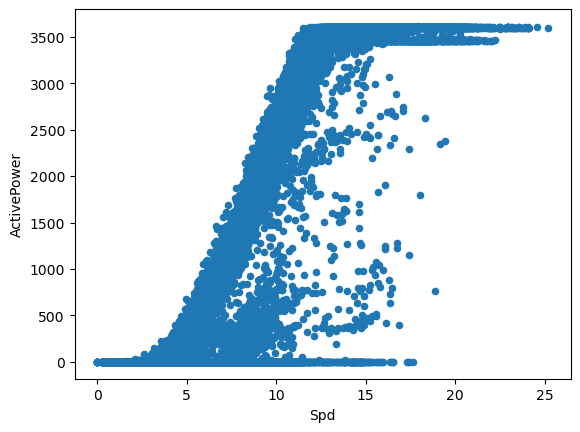

In [16]:
data.plot.scatter('Spd', 'ActivePower')

The plot submodule provides other graph functionality such as line-plots and bar-charts, the documentation for these can be viewed [here](https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.plot.html].

The documentation also provides information on all of the additional (vast) functionalities of pandas not covered in this tutorial, including a beginners 10-minutes to pandas guide less specific to this course. Although we will gradually cover more functionality of pandas as we go through the course, it is highly recommended if you have time to take a deeper look beyond this notebook to learn more about this package [here](https://pandas.pydata.org/docs/user_guide/index.html#user-guide).